<a href="https://colab.research.google.com/github/RFATS/TreeBasedModel_and_DNN/blob/me/01_ML_DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DecisionTree**

# **1. Decision Tree(CART : Classification and Regression Tree)**

**모델구분**  
- **`Decision Tree`** 모델은 **supervised learning**모델.  
- **prediction/classification이 모두 가능**

**모델 구조 및 특징**  
- 노드단위로 구성되어 나무가 가지를 펼쳐 나가는 듯한 직관적인 모델 구조를 갖는다.  
- 학습데이터를 100% 정확도로 예측/분류가 가능하다.  
- 위 특징으로 인해 모델 구조적으로 overfitting 문제가 있어 가지치기를 통한 해결이 필요하다.  

**학습**  
- 불순도를 기반으로 스무고개 게임을 하듯 여러 개의 hypothesis을 데이터에 반영하고 이를 바탕으로 decision boundary(결정경계)를 생성  
- 결정경계에 속한 데이터를 예측/분류 결과에 사용한다.  

**효과 및 활용**  
- ML, DL모델을 통틀어 예측/분류 결과에 따른 해석이 가장 좋다.  
- 이에 따라 **모델 해석이 필요한 문제/필드에 사용**한다. ex)신용평가, 모델분류  

## **2. 모델구조**
- root node(뿌리노드) : 최상위 노드, 모든 샘플 포함  
- leaf node(잎노드) : 최하위 노드, 여기에 속한 샘플이 모델 예측/분류 결과에 사용  
- node(노드) : 결정경계에 해당하는 모든 영역을 노드로 판단한다.    
- 가지(branch) : 노드를 나누는 기준, 가정, hypothesis  
- 깊이(depth) : 뿌리 노드와 잎 노드 까지의 노드 갯수

<img src="https://raw.githubusercontent.com/overgroove/ML_lecture_image_data/main/image/27.png">

## **3. 모델학습**
### **3.1 impurity(불순도)**
- **`DecisionTree`** 모델이 데이터를 학습하는 과정에서 사용하는 수치척도   
- 정보화 이론에서 사용하는 Gini index, 혹은 entropy를 사용한다.  
- 결정경계에 포함 된 데이터 중 다른 클래스가 포함 된 경우 불순도가 높은 상태  
- 판단기준은 불순도 값이 0.5에 가까수록 impurity가 높고 0 혹은 1에 가까울 수록 purity(순도)가 높다.  
- 즉, 한 노드의 impurity가 가능한 많이 떨어지도록(순도가 올라가도록, 값이 0으로 수렴하게) 노드를 나눈다.

$$ Gini = 1 - \sum_1^n{(p_i)^2} $$

$$ Entropy = - \sum_1^n{p_ilog(p_i)} $$

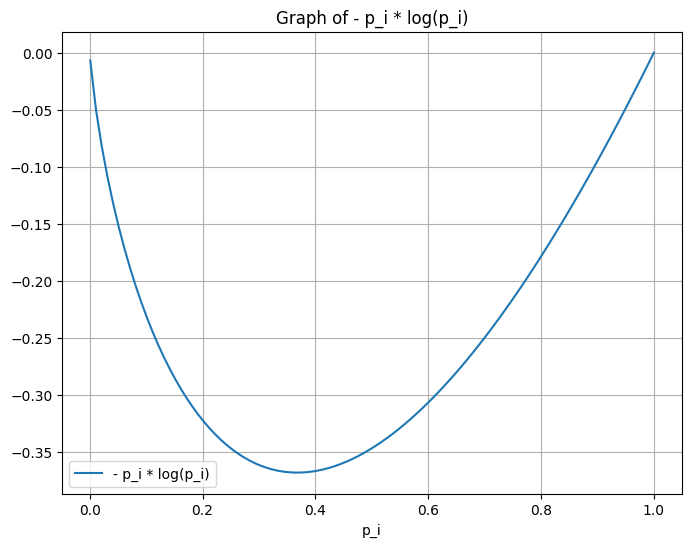

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define p_i values from a small epsilon to 1
p_i = np.linspace(0.001, 1, 100)

# Calculate p_i * log(p_i)
y = p_i * np.log(p_i)
# y = np.log(p_i)

# Plot the function
plt.figure(figsize=(8, 6))
plt.plot(p_i, y, label='- p_i * log(p_i)')
plt.title('Graph of - p_i * log(p_i)')
plt.xlabel('p_i')
# plt.ylabel('- p_i * log(p_i)')
plt.grid(True)
plt.legend()
plt.show()

### **3.2 Gini index**
위 예시에서 뿌리 노드 기준 지니계수 계산법  
class1 : 삼각형  
class2 : 동그라미  
>X < 0
>> True = class1 3개, class2 4개  
$1 - ({3 \over 3+4})^2 - ({4 \over 3+4})^2 = 0.48$  
False = class1 4개, class2 3개  
$1 - ({4 \over 4+3})^2 - ({3 \over 4+3})^2 = 0.48$  
total Gini 계수  
$1 - ({7 \over 7+7})0.48 - ({7 \over 7+7})0.48 = 0.52$


위 예시에서 잎 노드 기준 지니계수 계산법  
class1 : 삼각형  
class2 : 동그라미  
>Y < 1
>> True = class1 3개, class2 0개  
$1 - ({3 \over 3})^2 - ({0 \over 3})^2 = 0$  
False = class1 0개, class2 4개  
$1 - ({0 \over 4})^2 - ({4 \over 4})^2 = 0$  
total Gini 계수  
$1 - ({3 \over 3+4})0 - ({4 \over 3+4})0 = 1$

위의 예시에서 계산한 total Gini index가 **`DecisionTree`** 모델이 학습을 하는 과정에서 불순도를 참고하는 수치가 되며  
이를 바탕으로 더 나은 선택(곧 gini index를 가장 많이 감소시키는 가정)을 하게 되는 결정경계를 생성한다.  
이를 greedy(탐욕화) 알고리즘이라 한다.

## **4. DecisionTreeClassifier 실습**

In [2]:
# 필요모듈 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [3]:
# scikit-learn iris 데이터로드 / 로딩 데이터 확인
iris = load_iris(as_frame = True)
iris

{'data':      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
 0                  5.1               3.5                1.4               0.2
 1                  4.9               3.0                1.4               0.2
 2                  4.7               3.2                1.3               0.2
 3                  4.6               3.1                1.5               0.2
 4                  5.0               3.6                1.4               0.2
 ..                 ...               ...                ...               ...
 145                6.7               3.0                5.2               2.3
 146                6.3               2.5                5.0               1.9
 147                6.5               3.0                5.2               2.0
 148                6.2               3.4                5.4               2.3
 149                5.9               3.0                5.1               1.8
 
 [150 rows x 4 columns],
 'target': 0     

In [4]:
# 타겟데이터 분리
df = iris['frame']
y = df.target
X = df.drop(columns = 'target')
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
# 학습데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify = y)

In [6]:
# 모델 import
from sklearn.tree import DecisionTreeClassifier

In [7]:
# 모델 생성
dtc = DecisionTreeClassifier(max_depth=3, random_state=42)

In [8]:
# 모델 학습
dtc.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [9]:
# 모델 예측
dtc_pred = dtc.predict(X_test)
dtc_pred

array([2, 1, 2, 1, 2, 2, 1, 1, 0, 2, 0, 0, 2, 2, 0, 2, 1, 0, 0, 0, 1, 0,
       1, 2, 2, 1, 1, 1, 1, 0, 2, 2, 1, 0, 2, 0, 0, 0, 0, 2, 1, 0, 2, 2,
       1])

In [10]:
# 모델 평가
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, dtc_pred))
print(classification_report(y_test, dtc_pred))

[[15  0  0]
 [ 0 14  1]
 [ 0  0 15]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.93      0.97        15
           2       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



## **5. 분류 모델 평가방법 리뷰**

### **5.1 classification 모델평가**
> 분류모델인 **`DecisionTree`** 모델은 분류모델 평가 지표를 사용하여 모델을 평가한다.  
대표적인 모델평가 함수인 **오차행렬(confusion matrix)** 와 **분류평가표(classification report)** 를 사용한다.

### **5.2 confusion matrix(오차행렬)**  

<img src="https://raw.githubusercontent.com/overgroove/LG_electronics_ML/main/image/21.png">

TP - True Positive(실제값 1, 예측값 1로 정분류 된 갯수)  
FN - False Negative(실제값 1, 예측값 0으로 오분류 된 갯수)  
FP - Flase Positive(실제값 0, 예측값 1로 오분류 된 갯수)  
TN - True Negative(실제값 0, 예측값 0으로 정분류 된 갯수)

### **5.3 정확도(Accuracy)** - 전체 샘플 중 모델이 바르게 분류한 비율
<img src="https://raw.githubusercontent.com/overgroove/LG_electronics_ML/main/image/22.png">

$${TP + TN \over TP + FN + FP + TN}$$

### **5.4 정밀도(Precision)** - 모델이 positive로 분류한 것 중 실제값이 positive이 비율
<img src="https://raw.githubusercontent.com/overgroove/LG_electronics_ML/main/image/23.png">

$${TP \over TP + FP}$$

### **5.5 재현율(Recall)** - 실제값이 positive인 것 중 모델이 positive라 분류한 비율
<img src="https://raw.githubusercontent.com/overgroove/LG_electronics_ML/main/image/24.png">

$${TP \over TP + FN}$$

### **5.6 f1-score** - precision과 recall의 조화평균
<img src="https://raw.githubusercontent.com/overgroove/LG_electronics_ML/main/image/25.png">

$${2 * precision * recall \over precision + recall}$$  

## **6. 모델 해석을 위한 시각화 방법**
- **`DecisionTree`** 모델은 모든 Ai 모델을 통틀어 모델 전체 구조에 대한 설명이 모두 가능한 유일한 모델이다.  
- 모델의 최대 강점을 살려 전체 모델 구조에 대한 시각화를 진행한다.  
- `plot_tree()` 함수 활용

[Text(0.375, 0.875, 'petal length (cm) <= 2.45\ngini = 0.667\nsamples = 105\nvalue = [35, 35, 35]\nclass = setosa'),
 Text(0.25, 0.625, 'gini = 0.0\nsamples = 35\nvalue = [35, 0, 0]\nclass = setosa'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'petal width (cm) <= 1.55\ngini = 0.5\nsamples = 70\nvalue = [0, 35, 35]\nclass = versicolor'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'petal length (cm) <= 4.95\ngini = 0.057\nsamples = 34\nvalue = [0, 33, 1]\nclass = versicolor'),
 Text(0.125, 0.125, 'gini = 0.0\nsamples = 33\nvalue = [0, 33, 0]\nclass = versicolor'),
 Text(0.375, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = virginica'),
 Text(0.75, 0.375, 'petal width (cm) <= 1.7\ngini = 0.105\nsamples = 36\nvalue = [0, 2, 34]\nclass = virginica'),
 Text(0.625, 0.125, 'gini = 0.5\nsamples = 2\nvalue = [0, 1, 1]\nclass = versicolor'),
 Text(0.875, 0.125, 'gini = 0.057\nsamples = 34\nvalue = [0, 1, 33]\nclass = virginica')]

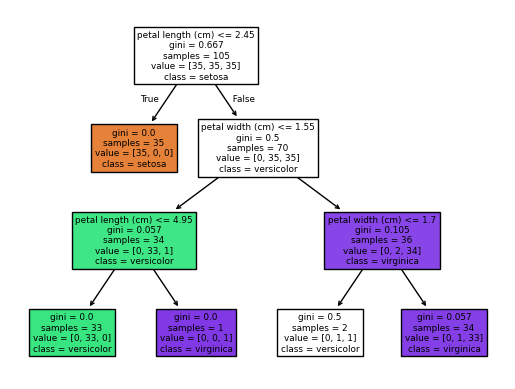

In [11]:
# 모델 시각화
from sklearn.tree import plot_tree
plot_tree(dtc, feature_names = iris.feature_names, class_names = iris.target_names, filled=True)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


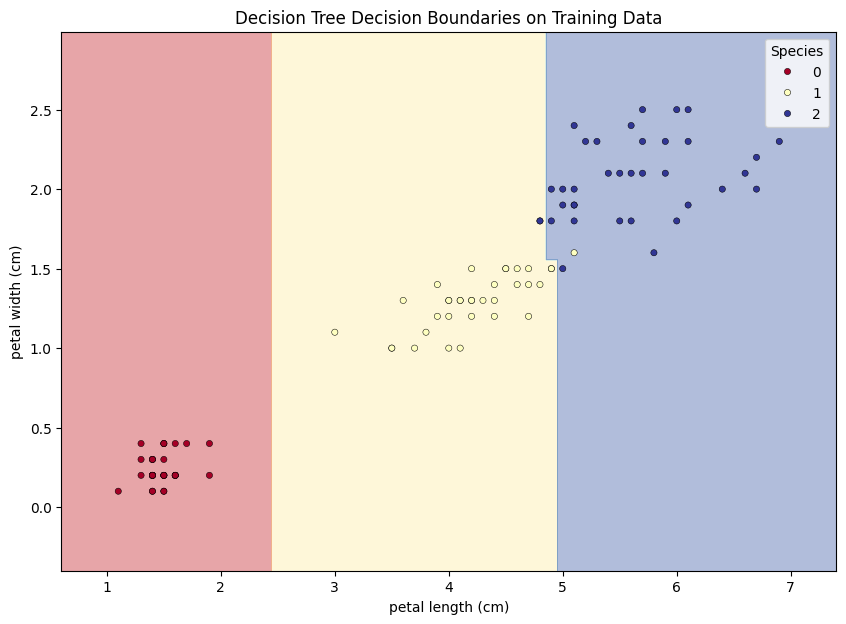

In [12]:
# 모델 학습 과정 시각화 및 분기선 그리기

# 필요한 특성만 선택
X_plot = X_train[['petal length (cm)', 'petal width (cm)']]

# 최소/최대 값 설정
x_min, x_max = X_plot.iloc[:, 0].min() - 0.5, X_plot.iloc[:, 0].max() + 0.5
y_min, y_max = X_plot.iloc[:, 1].min() - 0.5, X_plot.iloc[:, 1].max() + 0.5
h = 0.01 # step size in the mesh

# 그리드 생성
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# 모델 재훈련 (분기선 시각화를 위해 2D 데이터로)
# 기존 dtc 모델을 재활용하거나, 필요시 새로운 모델 생성
dt_visualize = DecisionTreeClassifier(max_depth=dtc.max_depth, random_state=dtc.random_state)
dt_visualize.fit(X_plot, y_train)

# 그리드 포인트에 대한 예측 수행
Z = dt_visualize.predict(np.c_[xx.ravel(), yy.ravel()])

# 예측 결과를 컬러맵으로 변환
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
# 결정 경계 그리기
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)

# 원본 데이터 포인트 그리기
sns.scatterplot(data=X_train, x='petal length (cm)', y='petal width (cm)', hue=y_train, palette='RdYlBu', edgecolor='k', s=20)

plt.title('Decision Tree Decision Boundaries on Training Data')
plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.legend(title='Species')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


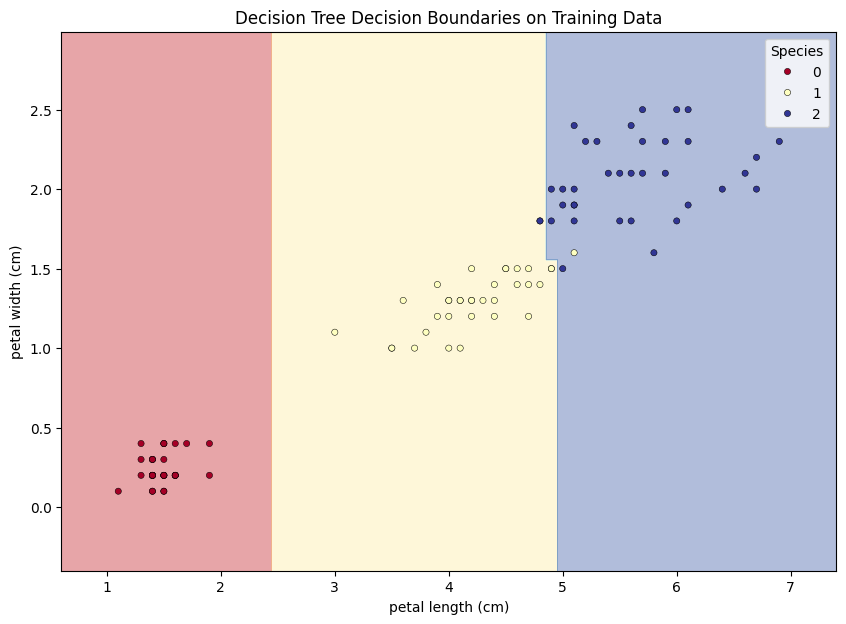

In [13]:
# 모델 학습 과정 시각화 및 분기선 그리기
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier # Ensure DecisionTreeClassifier is imported if not already in current scope

# 필요한 특성만 선택
X_plot = X_train[['petal length (cm)', 'petal width (cm)']]

# 최소/최대 값 설정
x_min, x_max = X_plot.iloc[:, 0].min() - 0.5, X_plot.iloc[:, 0].max() + 0.5
y_min, y_max = X_plot.iloc[:, 1].min() - 0.5, X_plot.iloc[:, 1].max() + 0.5
h = 0.01 # step size in the mesh

# 그리드 생성
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# 모델 재훈련 (분기선 시각화를 위해 2D 데이터로)
# 기존 dtc 모델을 재활용하거나, 필요시 새로운 모델 생성
dt_visualize = DecisionTreeClassifier(max_depth=dtc.max_depth, random_state=dtc.random_state)
dt_visualize.fit(X_plot, y_train)

# 그리드 포인트에 대한 예측 수행
Z = dt_visualize.predict(np.c_[xx.ravel(), yy.ravel()])

# 예측 결과를 컬러맵으로 변환
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
# 결정 경계 그리기
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)

# 원본 데이터 포인트 그리기
sns.scatterplot(data=X_train, x='petal length (cm)', y='petal width (cm)', hue=y_train, palette='RdYlBu', edgecolor='k', s=20)

plt.title('Decision Tree Decision Boundaries on Training Data')
plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.legend(title='Species')
plt.show()

In [14]:
from sklearn.tree import export_text
print(export_text(dtc))

|--- feature_2 <= 2.45
|   |--- class: 0
|--- feature_2 >  2.45
|   |--- feature_3 <= 1.55
|   |   |--- feature_2 <= 4.95
|   |   |   |--- class: 1
|   |   |--- feature_2 >  4.95
|   |   |   |--- class: 2
|   |--- feature_3 >  1.55
|   |   |--- feature_3 <= 1.70
|   |   |   |--- class: 1
|   |   |--- feature_3 >  1.70
|   |   |   |--- class: 2



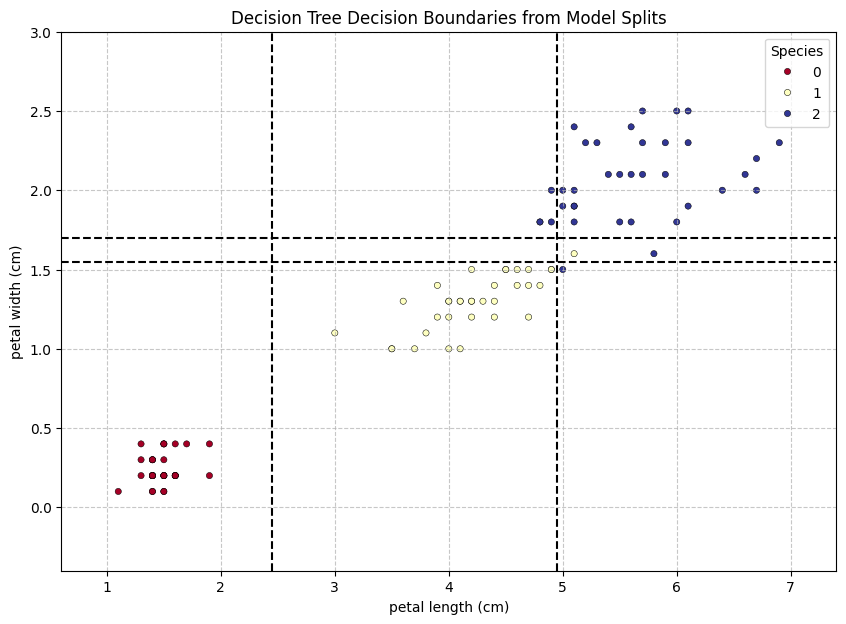

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 7))

# 원본 데이터 포인트 그리기 (이전 시각화와 동일)
sns.scatterplot(data=X_train, x='petal length (cm)', y='petal width (cm)', hue=y_train, palette='RdYlBu', edgecolor='k', s=20)

# 결정 경계선 그리기 (dtc.tree_ 속성에서 직접 추출)

# dtc.tree_.feature: 각 노드에서 분할에 사용된 특성 인덱스
# dtc.tree_.threshold: 각 노드에서 분할 기준 값

# feature_names 리스트를 사용하여 인덱스를 특성 이름에 매핑
feature_names = list(iris.feature_names)
petal_length_idx = feature_names.index('petal length (cm)')
petal_width_idx = feature_names.index('petal width (cm)')

n_nodes = dtc.tree_.node_count
children_left = dtc.tree_.children_left
children_right = dtc.tree_.children_right
feature = dtc.tree_.feature
threshold = dtc.tree_.threshold

# x축과 y축 범위 설정 (이전 시각화와 동일하게)
x_min, x_max = X_train['petal length (cm)'].min() - 0.5, X_train['petal length (cm)'].max() + 0.5
y_min, y_max = X_train['petal width (cm)'].min() - 0.5, X_train['petal width (cm)'].max() + 0.5

# 모든 노드를 순회하며 분할 기준 그리기
for i in range(n_nodes):
    if children_left[i] != children_right[i]:  # 분할이 있는 노드인 경우 (리프 노드가 아님)
        if feature[i] == petal_length_idx: # petal length (cm)로 분할
            plt.plot([threshold[i], threshold[i]], [y_min, y_max], 'k--', linewidth=1.5)
            # print(f"Vertical split at petal length (cm) = {threshold[i]:.2f}")
        elif feature[i] == petal_width_idx: # petal width (cm)로 분할
            plt.plot([x_min, x_max], [threshold[i], threshold[i]], 'k--', linewidth=1.5)
            # print(f"Horizontal split at petal width (cm) = {threshold[i]:.2f}")

plt.title('Decision Tree Decision Boundaries from Model Splits')
plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.legend(title='Species')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

위 텍스트 출력은 `dtc` 모델의 의사결정 규칙을 보여줍니다. 각 줄은 트리의 노드를 나타내며, `|---`는 트리의 깊이를 의미합니다. 예를 들어:

*   `petal length (cm) <= 2.45`는 첫 번째 분기 조건입니다.
*   `class: setosa`는 해당 노드에서 예측되는 클래스입니다.
*   `value=[35, 0, 0]`는 해당 노드에 도달한 샘플 중 각 클래스(setosa, versicolor, virginica)의 개수를 나타냅니다.

이러한 규칙들을 통해 모델이 어떤 특성의 어떤 값을 기준으로 데이터를 나누어 최종 클래스를 결정하는지 명확하게 이해할 수 있습니다.

In [16]:
dtc.tree_

`.tree_` 속성은 모델이 학습한 결정 트리의 저수준(low-level) 구조를 나타내는 객체입니다. 이 객체는 트리의 각 노드에 대한 다양한 정보를 포함하고 있습니다. 다음은 주요 속성들입니다:

In [17]:
print(f"Node Count: {dtc.tree_.node_count}")
print(f"Children Left: {dtc.tree_.children_left}")
print(f"Children Right: {dtc.tree_.children_right}")
print(f"Feature: {dtc.tree_.feature}")
print(f"Threshold: {dtc.tree_.threshold}")
print(f"Value (samples in each class at node): {dtc.tree_.value}")
print(f"Impurity (gini for classification): {dtc.tree_.impurity}")

Node Count: 9
Children Left: [ 1 -1  3  4 -1 -1  7 -1 -1]
Children Right: [ 2 -1  6  5 -1 -1  8 -1 -1]
Feature: [ 2 -2  3  2 -2 -2  3 -2 -2]
Threshold: [ 2.44999999 -2.          1.55000001  4.95000005 -2.         -2.
  1.69999999 -2.         -2.        ]
Value (samples in each class at node): [[[0.33333333 0.33333333 0.33333333]]

 [[1.         0.         0.        ]]

 [[0.         0.5        0.5       ]]

 [[0.         0.97058824 0.02941176]]

 [[0.         1.         0.        ]]

 [[0.         0.         1.        ]]

 [[0.         0.05555556 0.94444444]]

 [[0.         0.5        0.5       ]]

 [[0.         0.02941176 0.97058824]]]
Impurity (gini for classification): [0.66666667 0.         0.5        0.05709343 0.         0.
 0.10493827 0.5        0.05709343]


## **7. feature importance(변수중요도)**
- 트리 기반 모델은 모델 학습 후 학습에 사용한 어떤 변수가 모델 결과값에 중요하게 사용되었는지 확인이 가능하다.  
- imformation gain값을 정규화
- feature_importances_ 속성값을 통해 트리를 분기하는 과정에서 어떤 변수가 모델의 결과값에 중요하게 사용 되었는지 확인 가능

<BarContainer object of 4 artists>

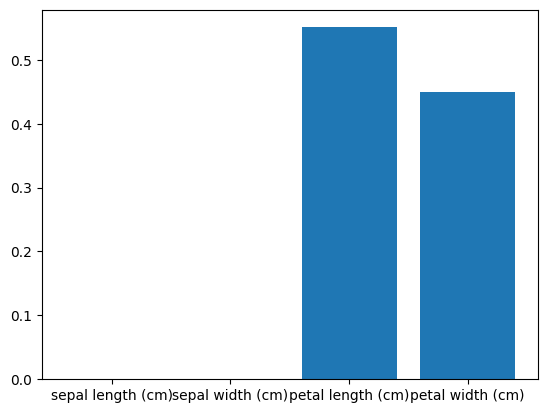

In [18]:
# feature importance 시각화
plt.bar(iris['feature_names'], dtc.feature_importances_)

# **8. 과적합(overfitting)**  
- 학습 데이터로 학습한 모델의 테스트 데이터 예측 성능이 떨어지는 경우  
- 모델이 일반화를 잘 못 시키는 상태. 실제 데이터 예측을 잘 못한다고 해석이 가능합니다.
<div align="center">
  <img src="https://raw.githubusercontent.com/overgroove/ML_lecture_image_data/main/image/16.png">
</div>

**overfitting**문제는 머신러닝 모델링에 있어 자주 발생하는 문제로서 모델의 복잡도를 개선하여 해결할 수 있습니다.  

### **8.1 pruning(가지치기)**
- **`Decision Tree`** 는 모든 **모든 잎 노드의 불순도가 0이 되는 순간까지 모델을 성장**시키면서 크기를 키워나간다.  
- 순수 노드로만 이루어진 트리 모델은 **training 데이터** 를 100% 정확도로 맞출 수 있고 이러한 특성 때문에 트리 모델은 **overfitting에 취약**하다.  
- 과적합 방지를 위해서는 **트리의 복잡도를 제어** 할 필요가 있다.

- 과적합 방지를 위한 모델링 파라메터  
> **`max_depth`** : 트리의 최대 깊이  
> `max_leaf_nodes` : 잎 노드의 최대개수  
> `min_sample_leaf` : 잎 노드 구성 최소 샘플 갯수  
> `min_sample_split` : 잎 노드 분지 최소 샘플 갯수

위의 모델플로팅 결과를 바탕으로 적정 복잡도를 지닌 depth를 선택 해준다면 overfitting 된 현재 모델을 개선할 수 있습니다.  
트리 모델의 경우 모델 복잡도를 제어하기 위한 하이퍼 파라메터 튜닝이 필수입니다.

In [19]:
# 모델 생성


In [20]:
# 모델 학습


In [21]:
# 모델 분류 결과값 확인


In [22]:
# 평가지표 출력


In [23]:
# 변수 중요도 확인


In [24]:
# 모델 구조 시각화


# **9. Decision Tree Regressor**
- **`Decision Tree`** 모델은 분류 및 예측 모델링에 모두 사용이 가능. 하지만 모델 구분은 필요.  
- 잎 노드에 속한 학습샘플의 값의 평균을 바탕으로 예측값을 결정한다.  
- 회귀모델 평가 방법인 MSE를 사용하여 각 노드에 속한 샘플에 적용하고 오차가 가장 작아지는 가정을 반영하는 방향으로 분기를 수행한다.

$$Cost = \sum_{i \in R_1} (y_i - \hat{y}_{R_1})^2 + \sum_{i \in R_2} (y_i - \hat{y}_{R_2})^2$$

<img src="https://raw.githubusercontent.com/overgroove/LG_electronics_ML/main/image/28.png">

## **10. Decision Tree Regressor 모델 특징**

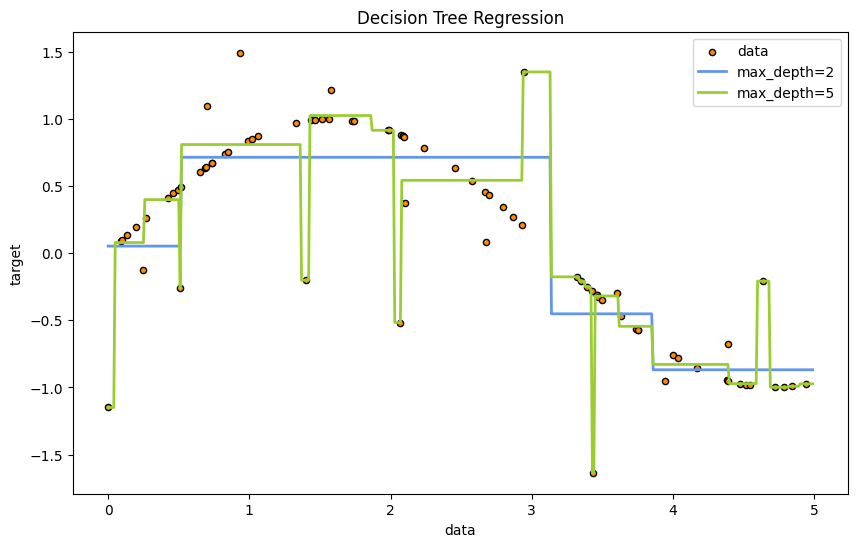

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor

rng = np.random.RandomState(1)
X = np.sort(5 * rng.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 3 * (0.5 - rng.rand(16))

regr_1 = DecisionTreeRegressor(max_depth=2)
regr_2 = DecisionTreeRegressor(max_depth=5)
regr_1.fit(X, y)
regr_2.fit(X, y)

X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_1 = regr_1.predict(X_test)
y_2 = regr_2.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X_test, y_1, color="cornflowerblue", label="max_depth=2", linewidth=2)
plt.plot(X_test, y_2, color="yellowgreen", label="max_depth=5", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

## **11. Decision Tree Regressor 실습**

In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

# 캘리포니아 주택 가격 데이터 로딩 (보스턴 데이터 대체)
df = pd.read_csv("https://raw.githubusercontent.com/overgroove/ML_lecture_image_data/refs/heads/main/data/boston.csv")

# 타겟 데이터 분할 (fetch_california_housing에서는 타겟 컬럼 이름이 'MedHouseVal'입니다.)
y = df['y']
X = df.drop(columns='y')

# 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 모델 생성
dtr = DecisionTreeRegressor(random_state=42)

# 모델 학습
dtr.fit(X_train, y_train)
# plot_tree(dtr)

# 모델 예측
dtr_pred = dtr.predict(X_test)

# 모델 평가지표 출력
print(f"Mean Squared Error: {root_mean_squared_error(y_test, dtr_pred):.2f}")
print(f"R-squared: {r2_score(y_test, dtr_pred):.2f}")

Mean Squared Error: 3.40
R-squared: 0.84


Mean Squared Error: 3.33
R-squared: 0.85


[Text(0.55, 0.9166666666666666, 'x[5] <= 6.941\nsquared_error = 87.897\nsamples = 354\nvalue = 23.016'),
 Text(0.2611111111111111, 0.75, 'x[12] <= 14.4\nsquared_error = 41.295\nsamples = 292\nvalue = 20.084'),
 Text(0.40555555555555556, 0.8333333333333333, 'True  '),
 Text(0.1, 0.5833333333333334, 'x[7] <= 1.385\nsquared_error = 26.114\nsamples = 178\nvalue = 23.47'),
 Text(0.044444444444444446, 0.4166666666666667, 'x[0] <= 10.109\nsquared_error = 91.577\nsamples = 4\nvalue = 44.475'),
 Text(0.022222222222222223, 0.25, 'squared_error = 0.0\nsamples = 3\nvalue = 50.0'),
 Text(0.06666666666666667, 0.25, 'squared_error = -0.0\nsamples = 1\nvalue = 27.9'),
 Text(0.15555555555555556, 0.4166666666666667, 'x[5] <= 6.543\nsquared_error = 14.233\nsamples = 174\nvalue = 22.987'),
 Text(0.1111111111111111, 0.25, 'x[12] <= 7.76\nsquared_error = 7.174\nsamples = 133\nvalue = 21.639'),
 Text(0.08888888888888889, 0.08333333333333333, 'squared_error = 2.279\nsamples = 25\nvalue = 23.776'),
 Text(0.133

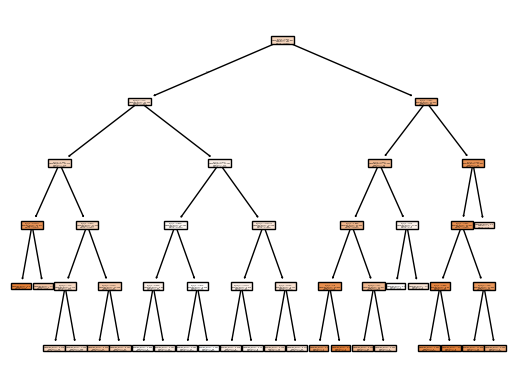

In [68]:
# 모델 생성
dtr = DecisionTreeRegressor(max_depth = 5, random_state=42)

# 모델 학습
dtr.fit(X_train, y_train)

# 모델 예측
dtr_pred = dtr.predict(X_test)

# 모델 평가지표 출력
print(f"Mean Squared Error: {root_mean_squared_error(y_test, dtr_pred):.2f}")
print(f"R-squared: {r2_score(y_test, dtr_pred):.2f}")

# 모델 시각화
plot_tree(dtr, filled=True)

<BarContainer object of 13 artists>

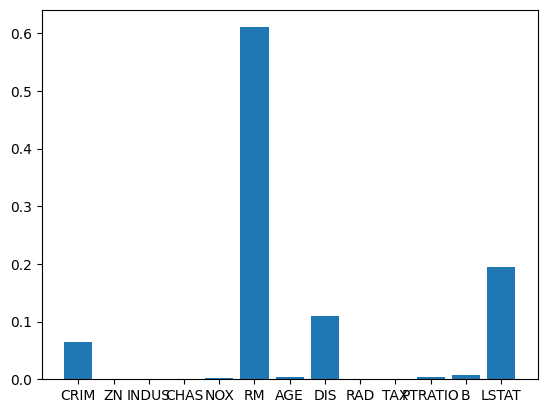

In [70]:
plt.bar(X_train.columns, dtr.feature_importances_)